# Library

In [276]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load Data

In [277]:
var_y = pd.read_csv('var_y.csv')
df = pd.read_csv('df.csv')

In [278]:
var_y.head()

,Y1,Y2,Y3,Y4,Y5,Y6,Y7,Y8,Y9,Y10,...,Y12,Y13,Y14,Y15,Y16,Y17,Y18,Y19,Y20,Kelas
0,2,5,5,5,4,5,5,5,5,3,...,2,5,4,4,2,5,4,3,5,LC09
1,2,2,4,3,4,2,4,4,4,3,...,4,4,2,2,2,5,4,5,5,LA09
2,3,2,5,4,2,3,4,5,3,3,...,4,4,3,3,2,3,3,3,2,LB09
3,2,3,4,4,3,3,4,2,2,3,...,4,3,4,4,2,3,3,4,3,LB09
4,1,1,2,3,3,3,4,3,3,4,...,2,2,3,3,2,1,4,4,1,LB09


In [279]:
df.head()

,Kelas,Gender,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10
0,LC09,Pria,3,3,2,2,3,3,2,3,2,2
1,LA09,Wanita,3,2,2,2,2,3,2,2,2,2
2,LB09,Pria,4,3,3,2,2,4,3,3,3,2
3,LB09,Pria,3,3,3,2,3,4,3,4,3,4
4,LB09,Wanita,3,3,2,2,3,3,3,3,3,3


# Analysis

In [280]:
print(var_y.shape)
var_y.info()

(48, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 21 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Y1      48 non-null     int64 
 1   Y2      48 non-null     int64 
 2   Y3      48 non-null     int64 
 3   Y4      48 non-null     int64 
 4   Y5      48 non-null     int64 
 5   Y6      48 non-null     int64 
 6   Y7      48 non-null     int64 
 7   Y8      48 non-null     int64 
 8   Y9      48 non-null     int64 
 9   Y10     48 non-null     int64 
 10  Y11     48 non-null     int64 
 11  Y12     48 non-null     int64 
 12  Y13     48 non-null     int64 
 13  Y14     48 non-null     int64 
 14  Y15     48 non-null     int64 
 15  Y16     48 non-null     int64 
 16  Y17     48 non-null     int64 
 17  Y18     48 non-null     int64 
 18  Y19     48 non-null     int64 
 19  Y20     48 non-null     int64 
 20  Kelas   48 non-null     object
dtypes: int64(20), object(1)
memory usage: 8.0+ KB


In [281]:
print(df.shape)
df.info()

(48, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Kelas   48 non-null     object
 1   Gender  48 non-null     object
 2   X1      48 non-null     int64 
 3   X2      48 non-null     int64 
 4   X3      48 non-null     int64 
 5   X4      48 non-null     int64 
 6   X5      48 non-null     int64 
 7   X6      48 non-null     int64 
 8   X7      48 non-null     int64 
 9   X8      48 non-null     int64 
 10  X9      48 non-null     int64 
 11  X10     48 non-null     int64 
dtypes: int64(10), object(2)
memory usage: 4.6+ KB


In [282]:
df[['Kelas', 'Gender']].value_counts()

Kelas  Gender
LB09   Pria      14
LC09   Pria      10
LA09   Pria       6
LB09   Wanita     6
LE09   Pria       6
LA09   Wanita     3
LD09   Pria       2
LE09   Wanita     1
Name: count, dtype: int64

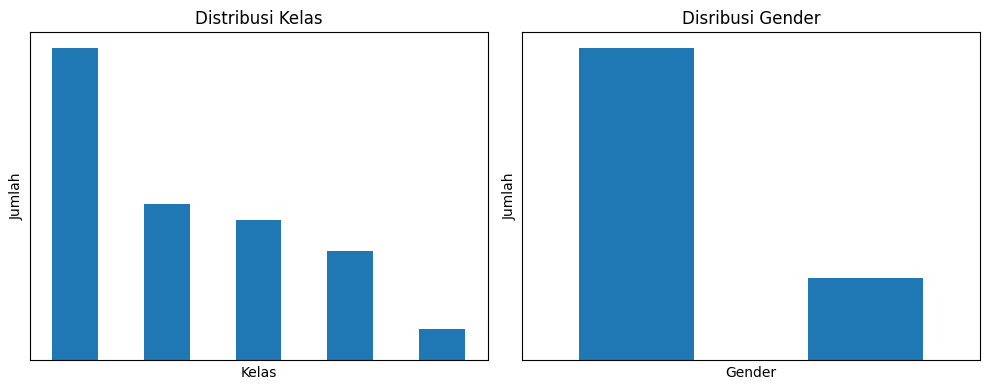

In [283]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

df['Kelas'].value_counts().plot(kind = 'bar', ax = ax[0])
ax[0].set_title('Distribusi Kelas')
ax[0].set_xlabel('Kelas')
ax[0].set_ylabel('Jumlah')
ax[0].set_xticks([])
ax[0].set_yticks([])

df['Gender'].value_counts().plot(kind = 'bar', ax = ax[1])
ax[1].set_xlabel('Gender')
ax[1].set_title('Disribusi Gender')
ax[1].set_ylabel('Jumlah')
ax[1].set_xticks([])
ax[1].set_yticks([])

plt.tight_layout()
plt.show()

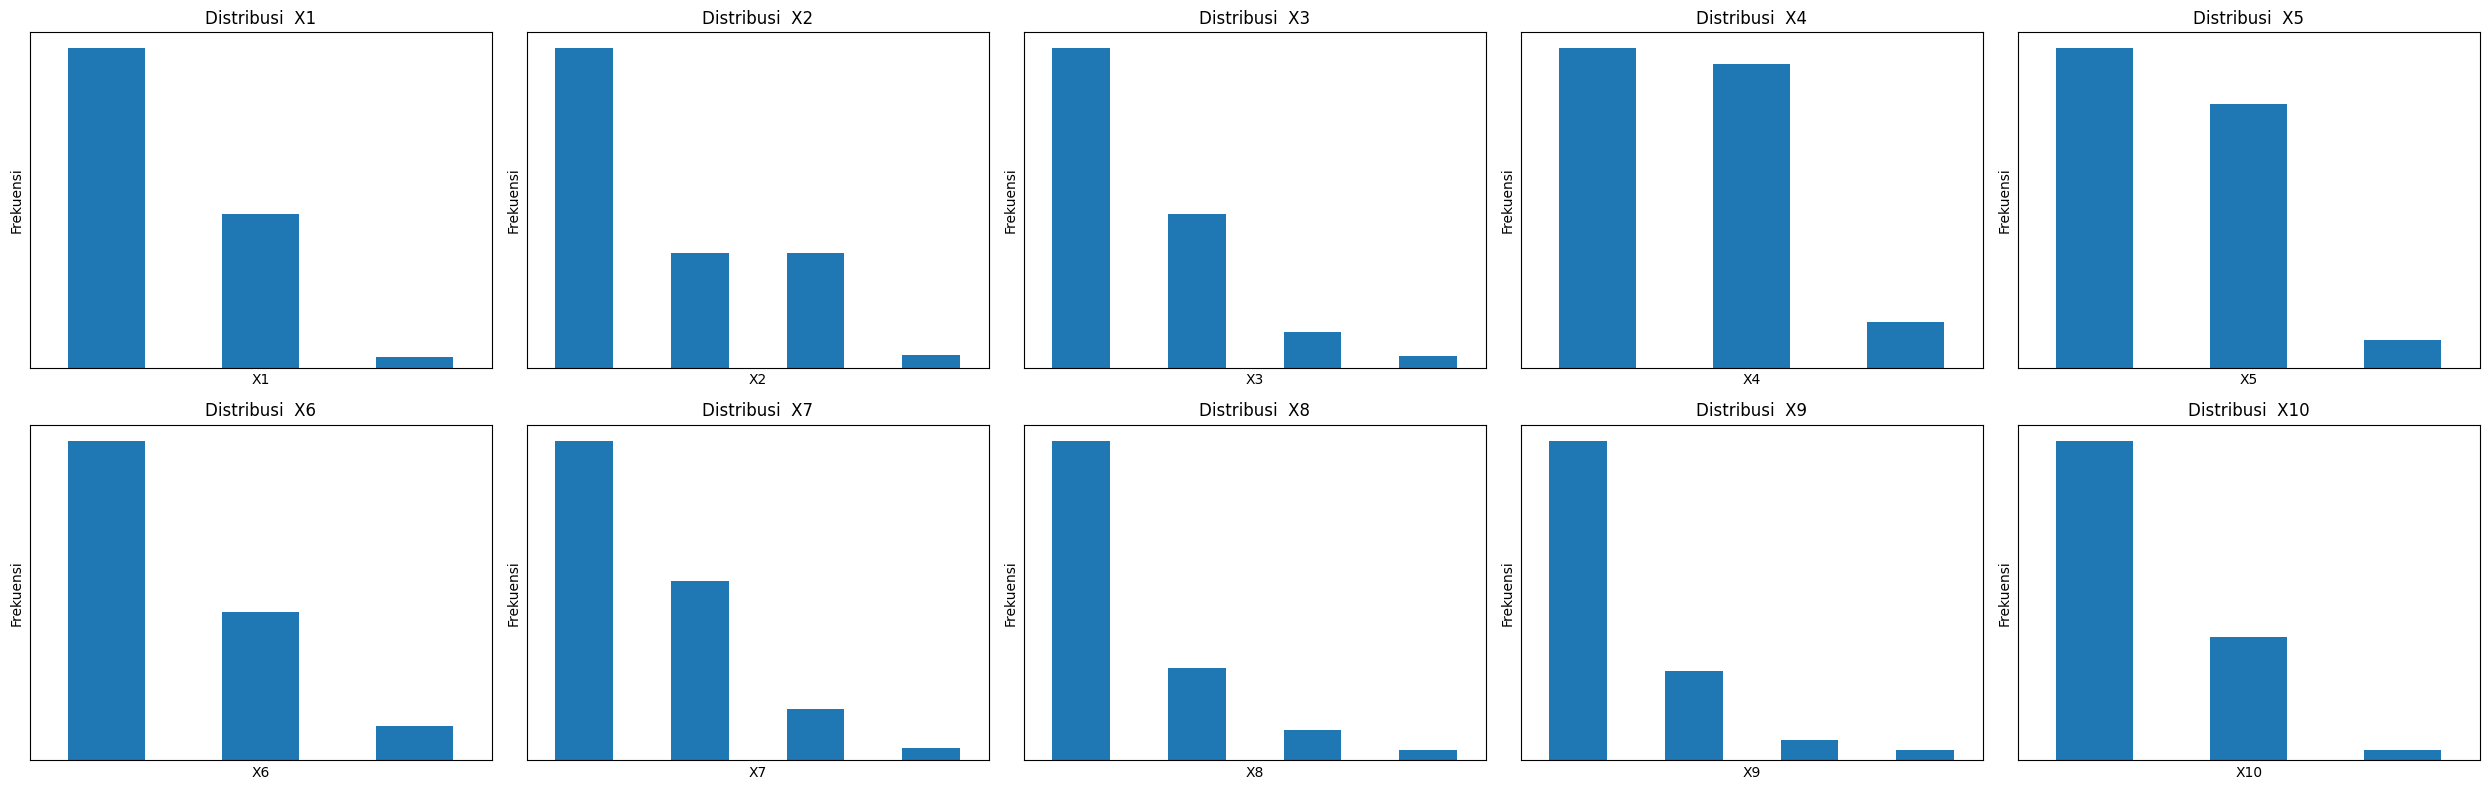

In [284]:
fig, ax = plt.subplots(2, 5, figsize=(25, 8))

ax = ax.flatten()

for i, col in enumerate(var_x.columns):
    var_x[col].value_counts().plot(kind = 'bar', ax = ax[i])
    ax[i].set_title(f'Distribusi  {col}')
    ax[i].set_xlabel(f'{col}')
    ax[i].set_ylabel('Frekuensi')
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    
plt.tight_layout()
plt.show()

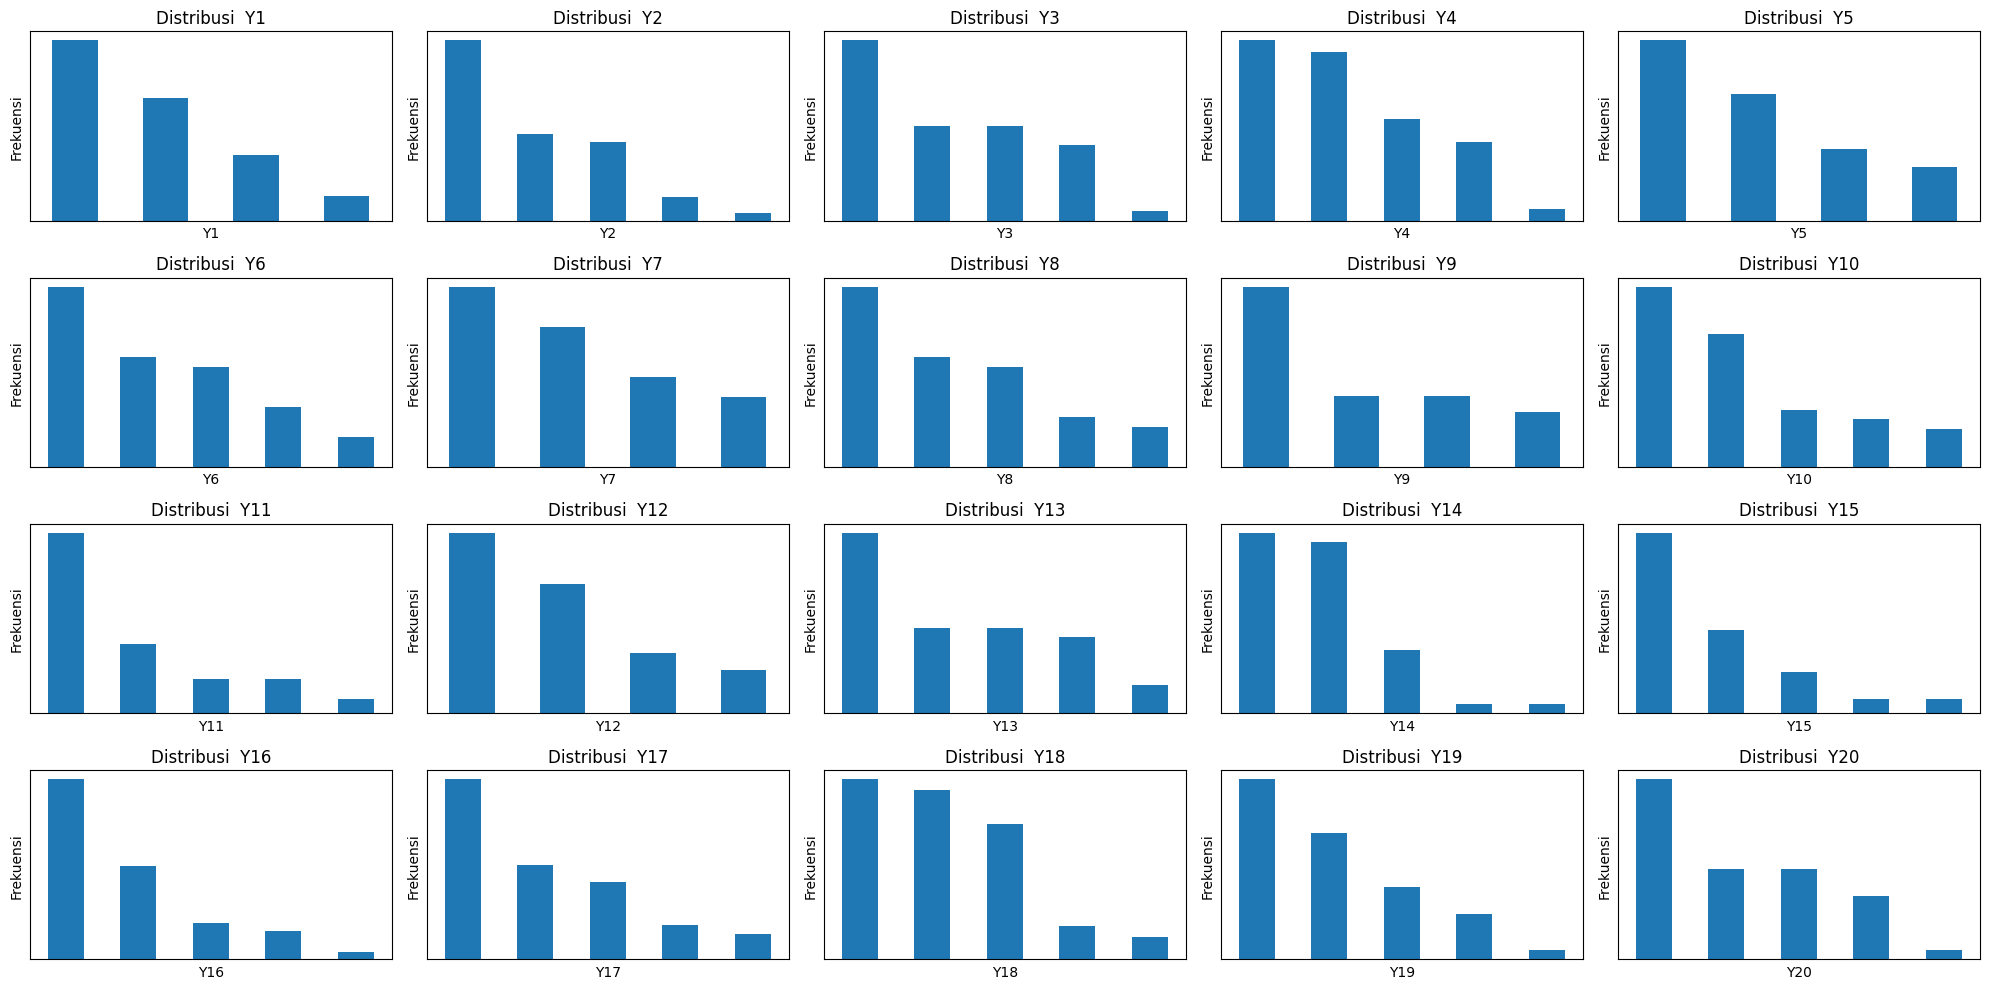

In [285]:
fig, ax = plt.subplots(4, 5, figsize=(20, 10))

ax = ax.flatten()

for i, col in enumerate(var_y.columns[:20]):
    var_y[col].value_counts().plot(kind = 'bar', ax = ax[i])
    ax[i].set_title(f'Distribusi  {col}')
    ax[i].set_xlabel(f'{col}')
    ax[i].set_ylabel('Frekuensi')
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    
plt.tight_layout()
plt.show()

# Feature Engineering

Populasi tiap Kelas (strata):
- LA09: 34 mahasiswa
- LB09: 35 mahasiswa
- LC09: 32 mahasiswa
- LD09: 
- LE09: 34 mahasiswa

In [286]:
# Populasi tiap kelas (isi sesuai data populasimu)
populasi = {
    'LA09':  34,
    'LB09':  35,
    'LC09':  32,
    'LD09': 42,
    'LE09': 34,
}
total_populasi = sum(populasi.values())

# Proporsi populasi
prop_populasi = {k: v/total_populasi for k, v in populasi.items()}

# Proporsi sampel
prop_sampel = df['Kelas'].value_counts(normalize=True).to_dict()

# Weight = proporsi populasi / proporsi sampel
weight_map = {
    kelas: prop_populasi[kelas] / prop_sampel[kelas]
    for kelas in populasi
}

var_y['weight'] = var_y['Kelas'].map(weight_map)

# Normalisasi
var_y['weight'] = var_y['weight'] / var_y['weight'].sum() * len(var_y)

# Cek hasilnya
summary = var_y.groupby('Kelas').agg(
    n_sampel=('Kelas', 'count'),
    weight=('weight', 'mean')
).assign(
    prop_sampel=lambda d: d['n_sampel']/len(var_y),
    prop_populasi=pd.Series(prop_populasi)
)
print(summary.round(3))

       n_sampel  weight  prop_sampel  prop_populasi
Kelas                                              
LA09          9   1.024        0.188          0.192
LB09         20   0.475        0.417          0.198
LC09         10   0.868        0.208          0.181
LD09          2   5.695        0.042          0.237
LE09          7   1.317        0.146          0.192


In [287]:
var_y.drop(columns = 'Kelas', inplace=True)

In [288]:
var_y.head()

,Y1,Y2,Y3,Y4,Y5,Y6,Y7,Y8,Y9,Y10,...,Y12,Y13,Y14,Y15,Y16,Y17,Y18,Y19,Y20,weight
0,2,5,5,5,4,5,5,5,5,3,...,2,5,4,4,2,5,4,3,5,0.867797
1,2,2,4,3,4,2,4,4,4,3,...,4,4,2,2,2,5,4,5,5,1.024482
2,3,2,5,4,2,3,4,5,3,3,...,4,4,3,3,2,3,3,3,2,0.474576
3,2,3,4,4,3,3,4,2,2,3,...,4,3,4,4,2,3,3,4,3,0.474576
4,1,1,2,3,3,3,4,3,3,4,...,2,2,3,3,2,1,4,4,1,0.474576


# Modeling

## Clustering

In [289]:
kmeans = KMeans(n_clusters = 4, random_state=42)
cluster_sample = var_y.drop(columns = ['weight'])
kmeans.fit(cluster_sample)

KMeans(n_clusters=4, random_state=42)

In [290]:
var_y['target'] = kmeans.labels_
df['target'] = kmeans.labels_

In [291]:
# ── Mapping cluster → stress level ───────────────────────────
# Hitung mean skor total per cluster
cluster_means = cluster_sample.copy()
cluster_means['target'] = kmeans.labels_
mean_per_cluster = cluster_means.groupby('target').mean().mean(axis=1)

# Ranking: mean terendah = level 1 (stres rendah), tertinggi = level 4
stress_map = mean_per_cluster.rank().astype(int).to_dict()
var_y['stress_level'] = var_y['target'].map(stress_map)
df['stress_level']    = df['target'].map(stress_map)

print("Mapping cluster → stress level:")
print(pd.DataFrame({
    'mean_skor': mean_per_cluster.round(2),
    'stress_level': stress_map
}).sort_values('stress_level'))

Mapping cluster → stress level:
   mean_skor  stress_level
3       2.60             1
0       2.98             2
2       3.36             3
1       3.66             4


In [292]:
# ── Distribusi weighted ───────────────────────────────────────
cluster_dist = var_y.groupby('stress_level').agg(
    n_responden=('stress_level', 'count'),
    weight_total=('weight', 'sum')
)
cluster_dist['proporsi_weighted'] = (
    cluster_dist['weight_total'] / cluster_dist['weight_total'].sum()
)
print("\nDistribusi stress level (weighted):")
print(cluster_dist.round(3))


Distribusi stress level (weighted):
              n_responden  weight_total  proporsi_weighted
stress_level                                              
1                      13         9.898              0.206
2                      20        22.091              0.460
3                       7         9.935              0.207
4                       8         6.076              0.127


In [293]:
score = silhouette_score(cluster_sample, kmeans.labels_)
print(f"Silhouette Score: {score:.3f}")

Silhouette Score: 0.121


In [294]:
df.head(15)

,Kelas,Gender,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,target,stress_level
0,LC09,Pria,3,3,2,2,3,3,2,3,2,2,1,4
1,LA09,Wanita,3,2,2,2,2,3,2,2,2,2,0,2
2,LB09,Pria,4,3,3,2,2,4,3,3,3,2,2,3
3,LB09,Pria,3,3,3,2,3,4,3,4,3,4,2,3
4,LB09,Wanita,3,3,2,2,3,3,3,3,3,3,3,1
5,LB09,Pria,4,4,3,2,2,4,2,3,3,3,0,2
6,LB09,Pria,3,3,2,3,3,3,3,3,3,3,2,3
7,LB09,Pria,3,2,2,2,2,3,2,2,1,2,1,4
8,LA09,Pria,3,3,2,3,2,2,2,2,3,2,1,4
9,LA09,Wanita,3,3,3,2,2,3,3,3,3,3,0,2


In [295]:
df['stress_level'].value_counts()

stress_level
2    20
1    13
4     8
3     7
Name: count, dtype: int64